In [ ]:
from nn import MLP,Value,BCELoss,Accuracy,Layer,Neuron
import numpy as np
import math
import random

In [303]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X,y = make_moons(n_samples=100,noise=0.1)

In [304]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [305]:
model = MLP(2,[16,16,1])
model

Multi Layer Perceptron of :

[Layer of :
[ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2), 
ReLUNeuron(2)] ,

Layer of :
[ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16), 
ReLUNeuron(16)] ,

Layer of :
[LinearNeuron(16)]]

In [307]:
epochs = 100
batch_size = 80

for epoch in range(epochs):
  ri = np.random.permutation(len(X_train))[:batch_size]
  Xb , yb = X_train[ri],y_train[ri]
  Xb = [list(map(Value,xrow)) for xrow in Xb]

  loss_fn = BCELoss()
  acc = Accuracy()
  y_logits = list(map(model,Xb))
  y_pred = [yi.sigmoid() for yi in y_logits]

  alpha = 1e-4
  data_loss = loss_fn(y_pred,yb)
  reg_loss = alpha * model.l2_regu()
  loss = data_loss + reg_loss

  model.zero_grad()
  loss.backward()
  model.step()

  train_acc = acc(y_pred,yb)
  X_t = [list(map(Value,xr)) for xr in X_test]
  test_logits = list(map(model,X_t))
  test_pred = [yi.sigmoid() for yi in test_logits]
  test_acc = acc(test_pred,y_test)

  if(epoch % 9 ==0):
    print(f"Epoch {epoch} | Train Accuracy : {train_acc} | Test Accuracy : {test_acc}")



Epoch 0 | Train Accuracy : 0.9 | Test Accuracy : 0.75
Epoch 9 | Train Accuracy : 0.8875 | Test Accuracy : 0.75
Epoch 18 | Train Accuracy : 0.9125 | Test Accuracy : 0.8
Epoch 27 | Train Accuracy : 0.9125 | Test Accuracy : 0.8
Epoch 36 | Train Accuracy : 0.9125 | Test Accuracy : 0.8
Epoch 45 | Train Accuracy : 0.9125 | Test Accuracy : 0.8
Epoch 54 | Train Accuracy : 0.9125 | Test Accuracy : 0.8
Epoch 63 | Train Accuracy : 0.9125 | Test Accuracy : 0.8
Epoch 72 | Train Accuracy : 0.9125 | Test Accuracy : 0.8
Epoch 81 | Train Accuracy : 0.9125 | Test Accuracy : 0.8
Epoch 90 | Train Accuracy : 0.9125 | Test Accuracy : 0.8
Epoch 99 | Train Accuracy : 0.9125 | Test Accuracy : 0.8


In [312]:
def predict(input):
  out = []
  for i in input:
    out.append(1 if i.data > 0.5 else 0)
  return out

y_pred = predict(test_pred)

<Axes: >

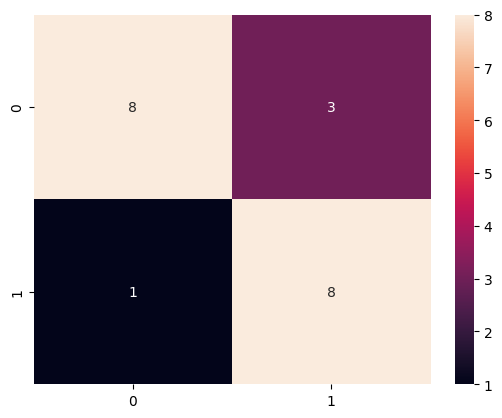

In [313]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)